# Wprowadzenie do Listy 2

Ten notatnik przygotowuje do pracy nad algorytmami z listy:
- drzewo decyzyjne (klasyfikacja, interpretacja reguł, feature importance),
- regresja liniowa (rozwiązanie analityczne i gradient descent),
- skalowanie cech i interpretacja wag,
- metryki klasyfikacji i regresji,
- bias-variance tradeoff, krzywe złożoności, problem ekstrapolacji.

**Nie** ma tu gotowych rozwiązań zadań z listy. Zamiast tego są:
- małe, sztuczne zbiory danych,
- intuicja matematyczna,
- proste eksperymenty,
- wspólny styl pracy z modelami: `fit(X, y)` i `predict(X)`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
np.random.seed(42)


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


## Najpierw pipeline, potem algorytm

Niezależnie od algorytmu trzymaj się stałego schematu:
- wybierz `X` i `y`,
- wykonaj podział na zbiór treningowy i testowy,
- dopiero na treningu dopasuj model,
- oceń model na teście,

Pamiętaj od początku o **data leakage** -- nie wolno używać informacji ze zbioru testowego podczas treningu.

Rozmiar train: (30, 1) (30,)
Rozmiar test: (10, 1) (10,)


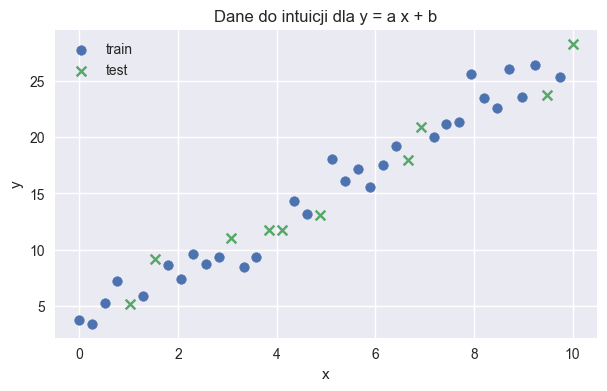

In [2]:
# Prosty zbiór regresyjny: jedna cecha, jedna zmienna celu.
X = np.linspace(0, 10, 40).reshape(-1, 1)
y = 2.5 * X[:, 0] + 3 + np.random.normal(0, 1.5, size=len(X))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Rozmiar train:", X_train.shape, y_train.shape)
print("Rozmiar test:", X_test.shape, y_test.shape)

plt.figure(figsize=(7, 4))
plt.scatter(X_train[:, 0], y_train, label="train")
plt.scatter(X_test[:, 0], y_test, label="test", marker="x")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dane do intuicji dla y = a x + b")
plt.legend()
plt.show()

### Drzewo decyzyjne jako seria pytań typu if/else

To łączy się z intuicją z Listy 1, gdzie reguły były tworzone ręcznie. Różnica jest taka, że teraz próg wybierany jest automatycznie na podstawie kryterium, np. **Giniego** albo **Entropii**.

Rodzic: Gini = 0.5000, Entropia = 1.0000



,próg,lewy,prawy,Gini po podziale,IG (Gini),Entropia po podziale,IG (Entropia)
0,1.5,[0],"[0, 0, 0, 1, 1, 1, 1]",0.4286,0.0714,0.8621,0.1379
1,2.5,"[0, 0]","[0, 0, 1, 1, 1, 1]",0.3333,0.1667,0.6887,0.3113
2,3.5,"[0, 0, 0]","[0, 1, 1, 1, 1]",0.2000,0.3000,0.4512,0.5488
3,4.5,"[0, 0, 0, 0]","[1, 1, 1, 1]",0.0000,0.5000,-0.0000,1.0000
4,5.5,"[0, 0, 0, 0, 1]","[1, 1, 1]",0.2000,0.3000,0.4512,0.5488
5,6.5,"[0, 0, 0, 0, 1, 1]","[1, 1]",0.3333,0.1667,0.6887,0.3113
6,7.5,"[0, 0, 0, 0, 1, 1, 1]",[1],0.4286,0.0714,0.8621,0.1379


Najlepszy próg wg Gini:     4.5  (IG = 0.5000)
Najlepszy próg wg Entropii: 4.5  (IG = 1.0000)


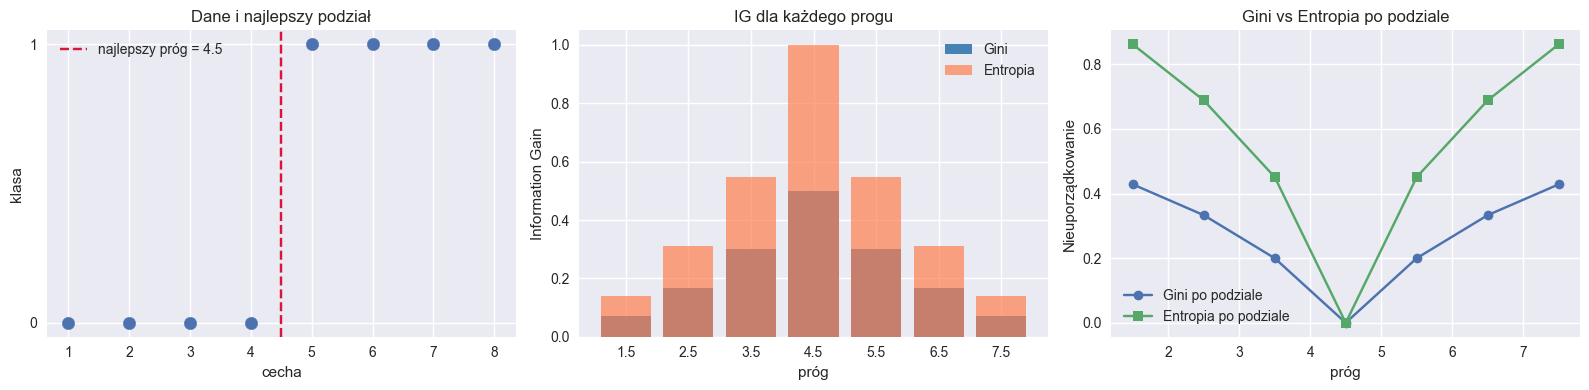

In [3]:
X_cls = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y_cls = np.array([0, 0, 0, 0, 1, 1, 1, 1])


def gini(y):
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)


def entropy_quick(y):
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p + 1e-12))


thresholds = (X_cls[:-1] + X_cls[1:]) / 2
parent_gini = gini(y_cls)
parent_entropy = entropy_quick(y_cls)
print(f"Rodzic: Gini = {parent_gini:.4f}, Entropia = {parent_entropy:.4f}")
print()

rows = []
for thr in thresholds:
    left_mask = X_cls < thr
    y_left, y_right = y_cls[left_mask], y_cls[~left_mask]
    n = len(y_cls)

    w_gini = len(y_left)/n * gini(y_left) + len(y_right)/n * gini(y_right)
    w_entr = len(y_left)/n * entropy_quick(y_left) + len(y_right)/n * entropy_quick(y_right)

    rows.append({
        "próg": thr,
        "lewy": str(y_left.tolist()),
        "prawy": str(y_right.tolist()),
        "Gini po podziale": round(w_gini, 4),
        "IG (Gini)": round(parent_gini - w_gini, 4),
        "Entropia po podziale": round(w_entr, 4),
        "IG (Entropia)": round(parent_entropy - w_entr, 4),
    })

results_df = pd.DataFrame(rows)
display(results_df)

best_gini = results_df.sort_values("IG (Gini)", ascending=False).iloc[0]
best_entr = results_df.sort_values("IG (Entropia)", ascending=False).iloc[0]
print(f"Najlepszy próg wg Gini:     {best_gini['próg']}  (IG = {best_gini['IG (Gini)']:.4f})")
print(f"Najlepszy próg wg Entropii: {best_entr['próg']}  (IG = {best_entr['IG (Entropia)']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(X_cls, y_cls, s=80, zorder=3)
axes[0].axvline(best_gini["próg"], color="crimson", linestyle="--", label=f"najlepszy próg = {best_gini['próg']}")
axes[0].set_yticks([0, 1])
axes[0].set_xlabel("cecha")
axes[0].set_ylabel("klasa")
axes[0].set_title("Dane i najlepszy podział")
axes[0].legend()

axes[1].bar(results_df["próg"].astype(str), results_df["IG (Gini)"], color="steelblue", label="Gini")
axes[1].bar(results_df["próg"].astype(str), results_df["IG (Entropia)"], color="coral", alpha=0.7, label="Entropia")
axes[1].set_xlabel("próg")
axes[1].set_ylabel("Information Gain")
axes[1].set_title("IG dla każdego progu")
axes[1].legend()

axes[2].plot(results_df["próg"], results_df["Gini po podziale"], "o-", label="Gini po podziale")
axes[2].plot(results_df["próg"], results_df["Entropia po podziale"], "s-", label="Entropia po podziale")
axes[2].set_xlabel("próg")
axes[2].set_ylabel("Nieuporządkowanie")
axes[2].set_title("Gini vs Entropia po podziale")
axes[2].legend()

plt.tight_layout()
plt.show()

Wymieszane dane: y = [0, 0, 1, 0, 1, 1, 0, 1]
Rodzic: Gini = 0.5000, Entropia = 1.0000



,próg,lewy,prawy,IG (Gini),IG (Entropia)
1,2.5,"[0, 0]","[1, 0, 1, 1, 0, 1]",0.1667,0.3113
3,4.5,"[0, 0, 1, 0]","[1, 1, 0, 1]",0.1250,0.1887
0,1.5,[0],"[0, 1, 0, 1, 1, 0, 1]",0.0714,0.1379
6,7.5,"[0, 0, 1, 0, 1, 1, 0]",[1],0.0714,0.1379
2,3.5,"[0, 0, 1]","[0, 1, 1, 0, 1]",0.0333,0.0488
4,5.5,"[0, 0, 1, 0, 1]","[1, 0, 1]",0.0333,0.0488
5,6.5,"[0, 0, 1, 0, 1, 1]","[0, 1]",0.0000,0.0000


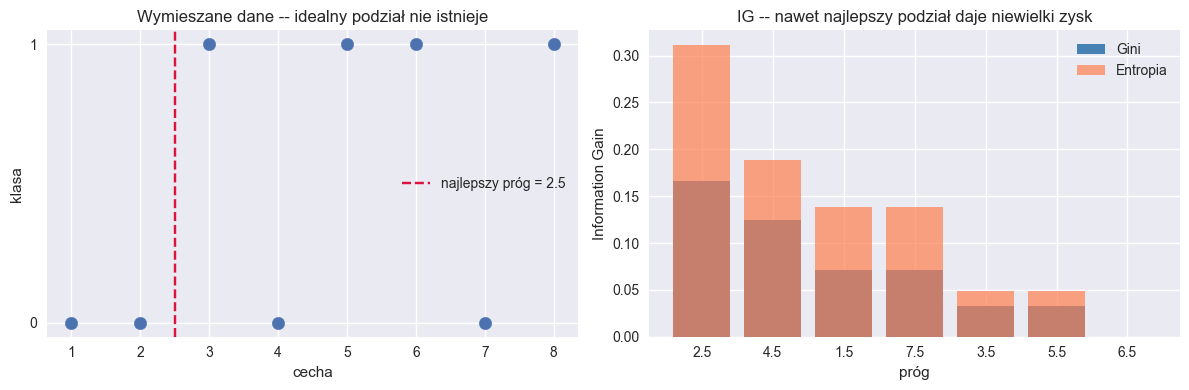

In [4]:
X_cls2 = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y_cls2 = np.array([0, 0, 1, 0, 1, 1, 0, 1])
thresholds2 = (X_cls2[:-1] + X_cls2[1:]) / 2

parent_g2 = gini(y_cls2)
parent_e2 = entropy_quick(y_cls2)
print(f"Wymieszane dane: y = {y_cls2.tolist()}")
print(f"Rodzic: Gini = {parent_g2:.4f}, Entropia = {parent_e2:.4f}\n")

rows2 = []
for thr in thresholds2:
    left_mask = X_cls2 < thr
    y_l, y_r = y_cls2[left_mask], y_cls2[~left_mask]
    n = len(y_cls2)
    wg = len(y_l)/n * gini(y_l) + len(y_r)/n * gini(y_r)
    we = len(y_l)/n * entropy_quick(y_l) + len(y_r)/n * entropy_quick(y_r)
    rows2.append({
        "próg": thr, "lewy": str(y_l.tolist()), "prawy": str(y_r.tolist()),
        "IG (Gini)": round(parent_g2 - wg, 4),
        "IG (Entropia)": round(parent_e2 - we, 4),
    })

messy_df = pd.DataFrame(rows2).sort_values("IG (Gini)", ascending=False)
display(messy_df)

best_thr2 = messy_df.iloc[0]["próg"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_cls2, y_cls2, s=80, zorder=3)
axes[0].axvline(best_thr2, color="crimson", linestyle="--", label=f"najlepszy próg = {best_thr2}")
axes[0].set_yticks([0, 1])
axes[0].set_xlabel("cecha")
axes[0].set_ylabel("klasa")
axes[0].set_title("Wymieszane dane -- idealny podział nie istnieje")
axes[0].legend()

axes[1].bar(messy_df["próg"].astype(str), messy_df["IG (Gini)"], color="steelblue", label="Gini")
axes[1].bar(messy_df["próg"].astype(str), messy_df["IG (Entropia)"], color="coral", alpha=0.7, label="Entropia")
axes[1].set_xlabel("próg")
axes[1].set_ylabel("Information Gain")
axes[1].set_title("IG -- nawet najlepszy podział daje niewielki zysk")
axes[1].legend()

plt.tight_layout()
plt.show()

### Praktyka: gotowe drzewo z `criterion="entropy"`

Jedno małe uruchomienie biblioteczne, żeby zobaczyć, jak teoria przekłada się na API:
- ustawiasz kryterium entropii w `scikit-learn`,
- widzisz wpływ `max_depth` na złożoność drzewa,
- te same pojęcia z teorii występują potem w kodzie.

max_depth=1 | głębokość=1 | liście=2 | accuracy_train=0.750
max_depth=2 | głębokość=2 | liście=3 | accuracy_train=0.750
max_depth=4 | głębokość=4 | liście=5 | accuracy_train=0.875


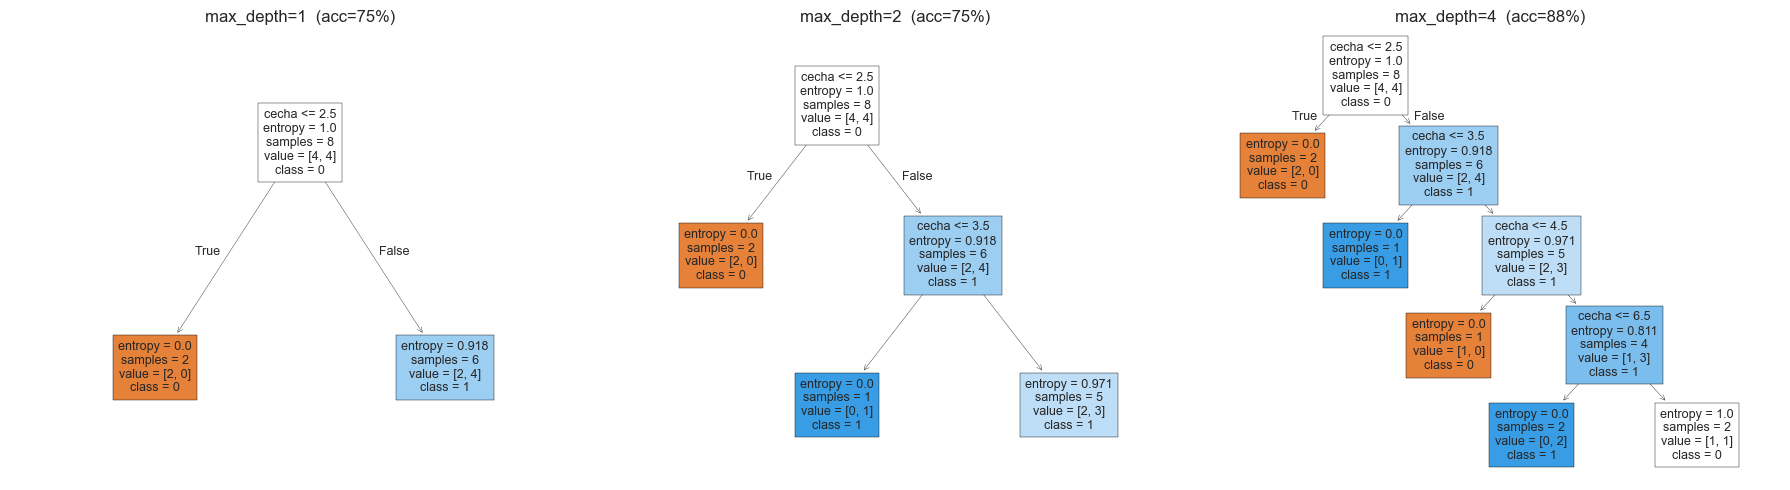


=== Reguły tekstowe (max_depth=4) ===
|--- cecha <= 2.50
|   |--- class: 0
|--- cecha >  2.50
|   |--- cecha <= 3.50
|   |   |--- class: 1
|   |--- cecha >  3.50
|   |   |--- cecha <= 4.50
|   |   |   |--- class: 0
|   |   |--- cecha >  4.50
|   |   |   |--- cecha <= 6.50
|   |   |   |   |--- class: 1
|   |   |   |--- cecha >  6.50
|   |   |   |   |--- class: 0

=== Feature importances ===
  max_depth=1: [1.]
  max_depth=2: [1.]
  max_depth=4: [1.]


In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

X_tree = np.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0], [8.0]])
y_tree = np.array([0, 0, 1, 0, 1, 1, 0, 1])

depths = [1, 2, 4]
trees = {}

for depth in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    clf.fit(X_tree, y_tree)
    preds = clf.predict(X_tree)
    acc = (preds == y_tree).mean()
    trees[depth] = clf
    print(
        f"max_depth={depth} | głębokość={clf.get_depth()} | "
        f"liście={clf.get_n_leaves()} | accuracy_train={acc:.3f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, depth in zip(axes, depths):
    plot_tree(trees[depth], feature_names=["cecha"], class_names=["0", "1"],
              filled=True, ax=ax, fontsize=9)
    acc = (trees[depth].predict(X_tree) == y_tree).mean()
    ax.set_title(f"max_depth={depth}  (acc={acc:.0%})")
plt.tight_layout()
plt.show()

print("\n=== Reguły tekstowe (max_depth=4) ===")
print(export_text(trees[4], feature_names=["cecha"]))

print("=== Feature importances ===")
for depth in depths:
    imp = trees[depth].feature_importances_
    print(f"  max_depth={depth}: {imp}")

### Metryki klasyfikacji: dlaczego accuracy nie wystarczy?

Na Liście 2 musisz policzyć metryki na zbiorze testowym. Accuracy jest naturalne, ale przy **niezbalansowanych** danych może mylić.

Przykład: jeśli 95% danych należy do klasy 0, model, który zawsze mówi "0", ma accuracy = 95%, ale jest bezużyteczny.

Dlatego warto znać:
- **Precision**: z tych, które model nazwał klasą 1, ile naprawdę jest klasą 1?
- **Recall**: z tych, które naprawdę są klasą 1, ile model trafił?
- **F1 Score**: średnia harmoniczna precision i recall.

\[
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
\]

,Accuracy,Precision,Recall,F1
model,,,,
Naiwny (zawsze 0),0.90,0.000,0.0,0.0
Lepszy model,0.95,0.667,1.0,0.8



=== Pełny raport (lepszy model) ===
              precision    recall  f1-score   support

     klasa 0       1.00      0.94      0.97        18
     klasa 1       0.67      1.00      0.80         2

    accuracy                           0.95        20
   macro avg       0.83      0.97      0.89        20
weighted avg       0.97      0.95      0.95        20



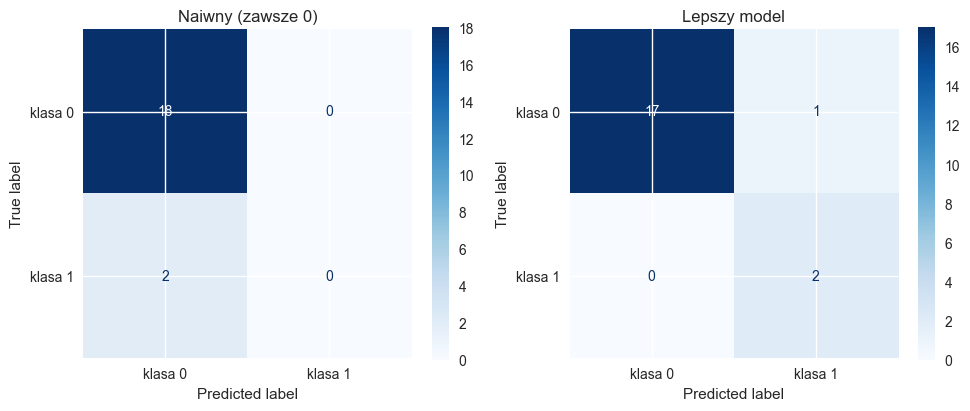

Macierz pomyłek pokazuje, że model naiwny NIE wykrywa klasy 1 (recall=0).
Lepszy model ma 1 FP, ale trafia obie instancje klasy 1.


In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

y_true = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1])
y_pred_naive = np.zeros(len(y_true), dtype=int)
y_pred_better = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1])

models = {"Naiwny (zawsze 0)": y_pred_naive, "Lepszy model": y_pred_better}

rows = []
for name, y_pred in models.items():
    rows.append({
        "model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    })

metrics_df = pd.DataFrame(rows).set_index("model")
display(metrics_df.round(3))

print("\n=== Pełny raport (lepszy model) ===")
print(classification_report(y_true, y_pred_better, target_names=["klasa 0", "klasa 1"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["klasa 0", "klasa 1"]).plot(ax=ax, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

print("Macierz pomyłek pokazuje, że model naiwny NIE wykrywa klasy 1 (recall=0).")
print("Lepszy model ma 1 FP, ale trafia obie instancje klasy 1.")

## Regresja Liniowa

Regresja liniowa dwoma metodami:
1. Rozwiązanie analityczne (macierz pseudoodwrotna).
2. Gradient descent.



Poniżej intuicja na przypadku jednowymiarowym -- na liście wymagane jest rozszerzenie tego rozwiązania na wiele cech.

### Regresja liniowa jako dopasowanie prostej

Na początek przypadek jednej zmiennej:

\[
y = a x + b
\]

Interpretacja:
- `a` mówi, jak bardzo zmienia się `y`, gdy `x` wzrośnie o 1,
- `b` to przewidywana wartość dla `x = 0`.

To dobry pomost od EDA do ML, bo widzisz:
- wykres punktowy,
- prostą przewidywań,
- reszty (`residuals`),
- błąd typu MSE.

Jednak pamiętamy o wersji wielowymiarowej, gdzie `y = w1*x1 + w2*x2 + ... + b`.

Zgadnięta prosta: y = 2.0x + 4.0
MSE = 4.833,  MAE = 1.745


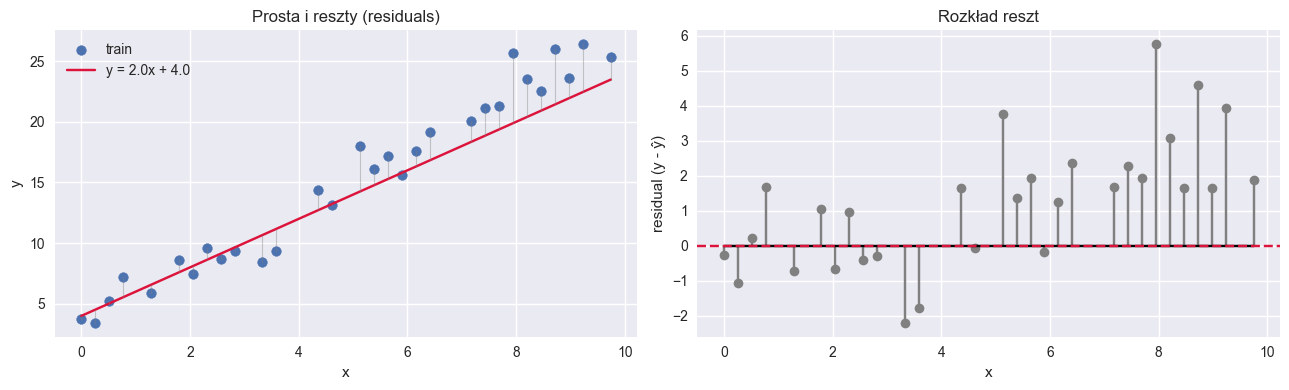

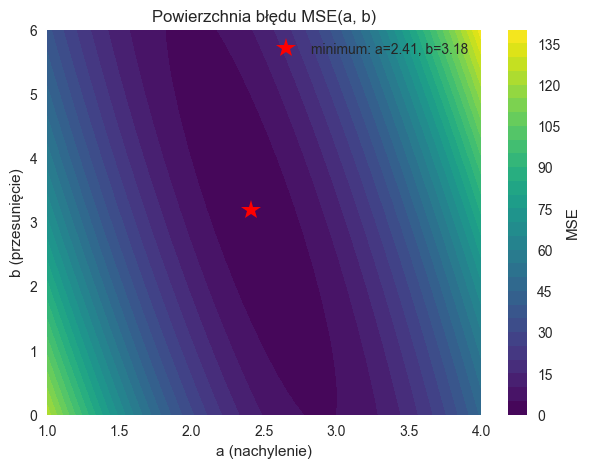

Najlepsza para z przeszukania: a=2.408, b=3.184, MSE=1.824


In [7]:
def predict_line(x, a, b):
    return a * x + b


a_guess = 2.0
b_guess = 4.0
y_pred_guess = predict_line(X_train[:, 0], a_guess, b_guess)
residuals_guess = y_train - y_pred_guess

print(f"Zgadnięta prosta: y = {a_guess}x + {b_guess}")
print(f"MSE = {mse(y_train, y_pred_guess):.3f},  MAE = {mae(y_train, y_pred_guess):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_train[:, 0], y_train, label="train")
x_sorted = np.sort(X_train[:, 0])
axes[0].plot(x_sorted, predict_line(x_sorted, a_guess, b_guess),
             color="crimson", label=f"y = {a_guess:.1f}x + {b_guess:.1f}")
for xi, yi, ri in zip(X_train[:, 0], y_train, y_pred_guess):
    axes[0].plot([xi, xi], [yi, ri], color="gray", alpha=0.4, linewidth=0.8)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Prosta i reszty (residuals)")
axes[0].legend()

axes[1].stem(X_train[:, 0], residuals_guess, linefmt="gray", markerfmt="o", basefmt="k-")
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("x")
axes[1].set_ylabel("residual (y - ŷ)")
axes[1].set_title("Rozkład reszt")
plt.tight_layout()
plt.show()

a_values = np.linspace(1.0, 4.0, 50)
b_values = np.linspace(0.0, 6.0, 50)
A, B = np.meshgrid(a_values, b_values)
Z = np.array([[mse(y_train, predict_line(X_train[:, 0], a, b)) for a in a_values] for b in b_values])

best_idx = np.unravel_index(Z.argmin(), Z.shape)
best_a, best_b = a_values[best_idx[1]], b_values[best_idx[0]]

fig, ax = plt.subplots(figsize=(7, 5))
cp = ax.contourf(A, B, Z, levels=30, cmap="viridis")
ax.plot(best_a, best_b, "r*", markersize=15, label=f"minimum: a={best_a:.2f}, b={best_b:.2f}")
plt.colorbar(cp, label="MSE")
ax.set_xlabel("a (nachylenie)")
ax.set_ylabel("b (przesunięcie)")
ax.set_title("Powierzchnia błędu MSE(a, b)")
ax.legend()
plt.show()

print(f"Najlepsza para z przeszukania: a={best_a:.3f}, b={best_b:.3f}, MSE={Z.min():.3f}")

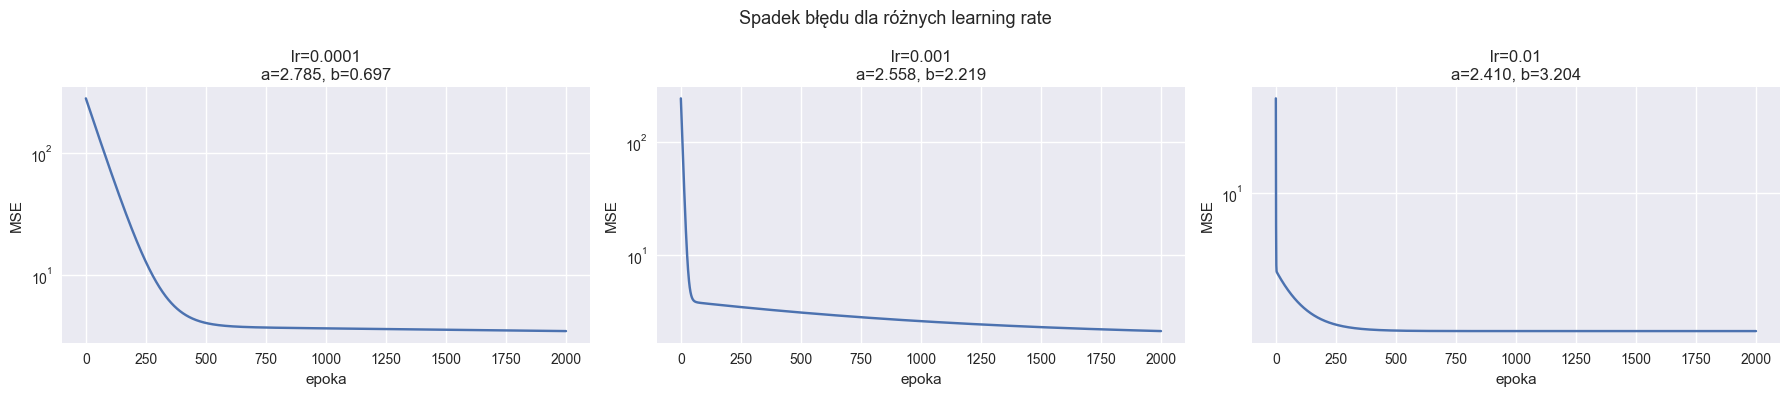


=== Wynik dla lr=0.001 ===
a = 2.5576,  b = 2.2190
Train MSE = 2.0805
Test MSE  = 2.4321
Test MAE  = 1.2756


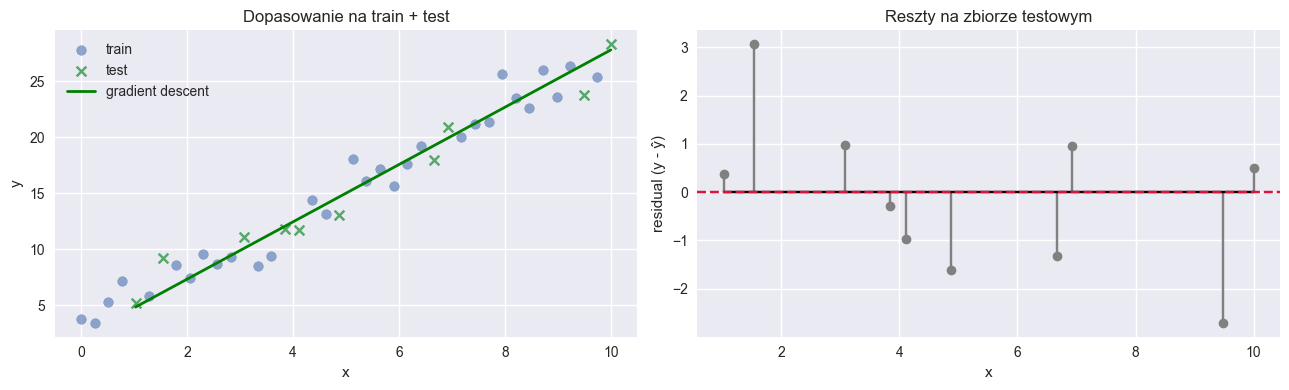

In [8]:
x_train_1d = X_train[:, 0]
n = len(x_train_1d)

learning_rates = [0.0001, 0.001, 0.01]
epochs = 2000
gd_results = {}

for lr in learning_rates:
    a_gd, b_gd = 0.0, 0.0
    history = []
    for _ in range(epochs):
        y_pred = a_gd * x_train_1d + b_gd
        error = y_pred - y_train
        a_gd -= lr * (2 / n) * np.sum(error * x_train_1d)
        b_gd -= lr * (2 / n) * np.sum(error)
        history.append(mse(y_train, a_gd * x_train_1d + b_gd))
    gd_results[lr] = {"a": a_gd, "b": b_gd, "history": history}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, lr in zip(axes, learning_rates):
    ax.plot(gd_results[lr]["history"])
    ax.set_title(f"lr={lr}\na={gd_results[lr]['a']:.3f}, b={gd_results[lr]['b']:.3f}")
    ax.set_xlabel("epoka")
    ax.set_ylabel("MSE")
    ax.set_yscale("log")
plt.suptitle("Spadek błędu dla różnych learning rate", fontsize=13)
plt.tight_layout()
plt.show()

best_lr = 0.001
a, b = gd_results[best_lr]["a"], gd_results[best_lr]["b"]
y_test_pred = a * X_test[:, 0] + b

print(f"\n=== Wynik dla lr={best_lr} ===")
print(f"a = {a:.4f},  b = {b:.4f}")
print(f"Train MSE = {mse(y_train, a * x_train_1d + b):.4f}")
print(f"Test MSE  = {mse(y_test, y_test_pred):.4f}")
print(f"Test MAE  = {mae(y_test, y_test_pred):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_sorted = np.sort(X_test[:, 0])
axes[0].scatter(X_train[:, 0], y_train, label="train", alpha=0.6)
axes[0].scatter(X_test[:, 0], y_test, label="test", marker="x")
axes[0].plot(x_sorted, a * x_sorted + b, color="green", linewidth=2, label="gradient descent")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Dopasowanie na train + test")
axes[0].legend()

residuals_test = y_test - y_test_pred
axes[1].stem(X_test[:, 0], residuals_test, linefmt="gray", markerfmt="o", basefmt="k-")
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("x")
axes[1].set_ylabel("residual (y - ŷ)")
axes[1].set_title("Reszty na zbiorze testowym")
plt.tight_layout()
plt.show()

### Rozwiązanie analityczne: macierz pseudoodwrotna (Metoda Najmniejszych Kwadratów)

Gradient descent to podejście iteracyjne. Ale dla regresji liniowej istnieje też rozwiązanie zamknięte:

\[
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
\]

Gdzie `X` zawiera kolumnę jedynek (intercept). To daje dokładne minimum MSE w jednym kroku.

Na Liście 2 musisz zaimplementować **oba** podejścia i porównać wyniki.

Rozwiązanie analityczne: a=2.410, b=3.204
Train MSE: 1.823
Test MSE:  2.056

Porównanie z gradient descent:  a=2.558, b=2.219
Różnica wag: |da|=0.147431, |db|=0.985133


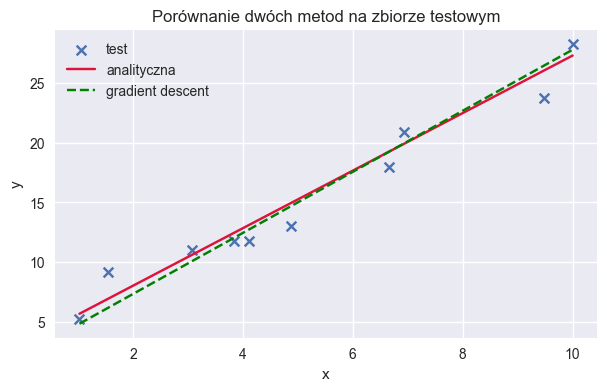

In [9]:
X_train_b = np.column_stack([np.ones(len(X_train)), X_train])
X_test_b = np.column_stack([np.ones(len(X_test)), X_test])

w_analytic = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

b_analytic, a_analytic = w_analytic[0], w_analytic[1]
print(f"Rozwiązanie analityczne: a={a_analytic:.3f}, b={b_analytic:.3f}")
print(f"Train MSE: {mse(y_train, X_train_b @ w_analytic):.3f}")
print(f"Test MSE:  {mse(y_test, X_test_b @ w_analytic):.3f}")

print(f"\nPorównanie z gradient descent:  a={a:.3f}, b={b:.3f}")
print(f"Różnica wag: |da|={abs(a_analytic - a):.6f}, |db|={abs(b_analytic - b):.6f}")

plt.figure(figsize=(7, 4))
plt.scatter(X_test[:, 0], y_test, label="test", marker="x")
x_line = np.linspace(X_test.min(), X_test.max(), 100)
plt.plot(x_line, a_analytic * x_line + b_analytic, color="crimson", label="analityczna")
plt.plot(x_line, a * x_line + b, color="green", linestyle="--", label="gradient descent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Porównanie dwóch metod na zbiorze testowym")
plt.legend()
plt.show()

### Dlaczego skalowanie cech ma znaczenie?

Przy regresji liniowej łatwo wpaść w pułapkę: "większa waga = ważniejsza cecha". To bywa mylące, jeśli cechy są w różnych skalach.

Przykład:
- wiek może być w przedziale `18-80`,
- dochód może mieć wartości rzędu `2000-20000`.

Wtedy sama wartość wagi nie jest jeszcze uczciwym porównaniem. Najpierw warto zobaczyć to na prostym eksperymencie, a dopiero potem łączyć z interpretacją modelu.

In [10]:
toy_df = pd.DataFrame(
    {
        "wiek": [20, 25, 30, 35, 40, 45],
        "dochod": [2000, 3500, 5000, 7000, 9000, 12000],
    }
)

scaler = StandardScaler()
scaled = scaler.fit_transform(toy_df)
scaled_df = pd.DataFrame(scaled, columns=toy_df.columns)

print("Przed standaryzacją:")
display(toy_df.describe().round(2))

print("\nPo standaryzacji:")
display(scaled_df.describe().round(2))

Przed standaryzacją:


,wiek,dochod
count,6.00,6.00
mean,32.50,6416.67
std,9.35,3693.46
min,20.00,2000.00
25%,26.25,3875.00
50%,32.50,6000.00
75%,38.75,8500.00
max,45.00,12000.00



Po standaryzacji:


,wiek,dochod
count,6.00,6.00
mean,0.00,-0.00
std,1.10,1.10
min,-1.46,-1.31
25%,-0.73,-0.75
50%,0.00,-0.12
75%,0.73,0.62
max,1.46,1.66


## Bias-Variance i Problem Czarnego Łabędzia

Na tę ocenę musisz:
- wymusić **underfitting** (np. `max_depth=1`, czysta regresja liniowa dla nieliniowych danych),
- wymusić **overfitting** (np. drzewo bez limitu głębokości, wielomian stopnia 15+),
- zbudować **krzywe złożoności**: pętla po stopniu wielomianu / głębokości drzewa, wykres Train Error vs Test Error, zaznaczony sweet spot,
- pokazać **Problem Czarnego Łabędzia**: predykcja przeuczonego modelu dla punktu 20% poza zakresem treningowym -- wielomian "eksploduje", model optymalny zachowuje się rozsądnie.

Zobacz:
- https://nustat.github.io/STAT303-3-class-notes/Bias_variance_code.html
- https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html

### Bias-variance tradeoff: za prosty model kontra za złożony model

To łączy kilka wątków naraz:
- regresję liniową,
- drzewa decyzyjne,
- interpretację błędu na train i test.

Intuicja:
- **wysoki bias**: model jest zbyt prosty i nie umie uchwycić zależności w danych,
- **wysoka variance**: model jest zbyt czuły na dane treningowe i słabiej uogólnia.

W praktyce:
- model zbyt prosty -> **underfitting**,
- model zbyt złożony -> **overfitting**.

Możesz to powiązać z:
- stopniem złożoności modelu regresyjnego,
- głębokością drzewa `max_depth`,
- jakością wyniku na zbiorze treningowym i testowym.

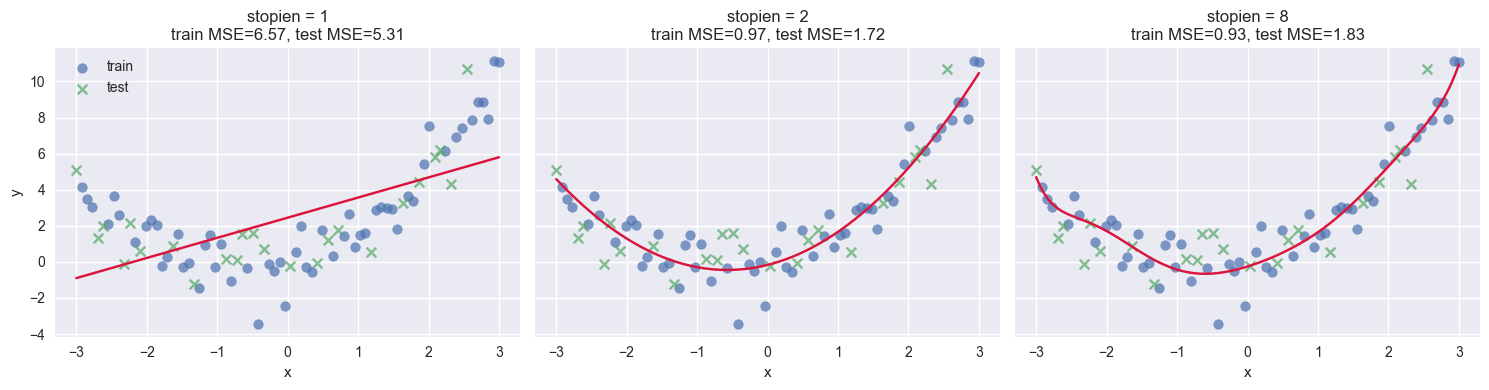

,stopien,train_mse,test_mse
0,1,6.566128,5.308338
1,2,0.965473,1.723760
2,8,0.925743,1.833753


In [11]:
# Prosty eksperyment: dane są lekko nieliniowe.
X_bv = np.linspace(-3, 3, 80)
y_bv = 0.8 * X_bv**2 + X_bv + np.random.normal(0, 1.2, size=len(X_bv))

X_train_bv, X_test_bv, y_train_bv, y_test_bv = train_test_split(
    X_bv, y_bv, test_size=0.3, random_state=42
)


def fit_poly_and_predict(x_train, y_train, x_test, degree):
    coeffs = np.polyfit(x_train, y_train, degree)
    y_train_pred = np.polyval(coeffs, x_train)
    y_test_pred = np.polyval(coeffs, x_test)
    return coeffs, y_train_pred, y_test_pred


degrees = [1, 2, 8]
summary = []
x_grid = np.linspace(X_bv.min(), X_bv.max(), 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, degree in zip(axes, degrees):
    coeffs, y_train_pred, y_test_pred = fit_poly_and_predict(
        X_train_bv, y_train_bv, X_test_bv, degree
    )
    y_grid = np.polyval(coeffs, x_grid)

    train_err = mse(y_train_bv, y_train_pred)
    test_err = mse(y_test_bv, y_test_pred)
    summary.append((degree, train_err, test_err))

    ax.scatter(X_train_bv, y_train_bv, label="train", alpha=0.7)
    ax.scatter(X_test_bv, y_test_bv, label="test", marker="x", alpha=0.7)
    ax.plot(x_grid, y_grid, color="crimson")
    ax.set_title(f"stopien = {degree}\ntrain MSE={train_err:.2f}, test MSE={test_err:.2f}")
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
axes[0].legend()
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary, columns=["stopien", "train_mse", "test_mse"])
display(summary_df)

# Sprawdź sam:
# Który model jest za prosty?
# Który model zaczyna za bardzo dopasowywać się do treningu?
# Czy najniższy błąd na train zawsze oznacza najlepszy model?

## Naiwny Bayes (BONUS -- poza zakresem Listy 2)

> **Uwaga:** Naiwny Bayes **nie** jest wymagany na Liście 2. Ta sekcja jest dodatkowa i może być użyteczna jako kontekst lub na późniejszych listach.

Dobry kontrast wobec drzewa i regresji. Model nie szuka prostej ani progu. Zamiast tego patrzy na:
- prawdopodobieństwa klas a priori,
- średnie i wariancje cech w klasach,
- prawdopodobieństwa warunkowe dla cech kategorialnych.

Warto zobaczyć:
- jak policzyć średnią i wariancję w danej klasie,
- dlaczego cecha niewidziana na treningu jest problemem,
- jak działa **Laplace smoothing**.

In [12]:
df_nb = pd.DataFrame(
    {
        "klasa": ["A", "A", "A", "B", "B", "B"],
        "wzrost": [160, 162, 165, 175, 178, 180],
        "zawod": ["student", "student", "pracownik", "pracownik", "pracownik", "lekarz"],
    }
)

display(df_nb)

print("Statystyki dla cechy ciągłej 'wzrost':")
for cls in sorted(df_nb["klasa"].unique()):
    subset = df_nb[df_nb["klasa"] == cls]
    mean_ = subset["wzrost"].mean()
    var_ = subset["wzrost"].var(ddof=0)
    prior = len(subset) / len(df_nb)
    print(f"Klasa={cls}: prior={prior:.2f}, średnia={mean_:.2f}, wariancja={var_:.2f}")

print("\nPrawdopodobieństwo zawodu w klasie A bez wygładzania:")
subset_A = df_nb[df_nb["klasa"] == "A"]
counts_A = subset_A["zawod"].value_counts()
print((counts_A / len(subset_A)).to_dict())

all_jobs = sorted(df_nb["zawod"].unique().tolist() + ["artysta"])
alpha = 1
laplace_probs = {}
for job in all_jobs:
    count = counts_A.get(job, 0)
    laplace_probs[job] = (count + alpha) / (len(subset_A) + alpha * len(all_jobs))

print("\nTo samo z Laplace smoothing dla klasy A:")
print(laplace_probs)
print("\nZauważ, że nawet niewidziany zawód 'artysta' nie ma już prawdopodobieństwa 0.")

,klasa,wzrost,zawod
0,A,160,student
1,A,162,student
2,A,165,pracownik
3,B,175,pracownik
4,B,178,pracownik
5,B,180,lekarz


Statystyki dla cechy ciągłej 'wzrost':
Klasa=A: prior=0.50, średnia=162.33, wariancja=4.22
Klasa=B: prior=0.50, średnia=177.67, wariancja=4.22

Prawdopodobieństwo zawodu w klasie A bez wygładzania:
{'student': 0.6666666666666666, 'pracownik': 0.3333333333333333}

To samo z Laplace smoothing dla klasy A:
{'artysta': 0.14285714285714285, 'lekarz': 0.14285714285714285, 'pracownik': np.float64(0.2857142857142857), 'student': np.float64(0.42857142857142855)}

Zauważ, że nawet niewidziany zawód 'artysta' nie ma już prawdopodobieństwa 0.
